In [2]:


from pathlib import Path

import pandas as pd
from sqlalchemy import create_engine
from sqlalchemy import text, bindparam

from nhs_waiting_lists import (
    __app_name__,
)
from nhs_waiting_lists.constants import TREATMENT_CODES
from nhs_waiting_lists.constants import proj_db_path, DB_FILE
from nhs_waiting_lists.utils.xdg import XDGBasedir
from nhs_waiting_lists.constants import LARGE_ACUTE_PROVIDER_CODES
import pandas as pd
from sqlalchemy import Engine
from sqlalchemy import text, bindparam
project_root = Path(XDGBasedir.get_data_dir(__app_name__))

DB_PATH = project_root / proj_db_path / DB_FILE
FILES_DIR = project_root / "files"

engine = create_engine(f"sqlite:///{DB_PATH}")

In [3]:

incomplete_query = text("""
                        SELECT i.*,
                               i.provider AS provider_code
                        FROM incomplete AS i
                                 JOIN provider AS p ON i.provider = p.provider
                        WHERE i.provider IN :provider_codes
                          AND treatment IN :treatment_codes
                          AND period >= '2024-01'
                        ORDER BY i.provider ASC, period ASC; \
                        """).bindparams(
    bindparam('provider_codes', expanding=True),
    bindparam('treatment_codes', expanding=True)
)

incomplete_df = pd.read_sql(incomplete_query, engine, params={
    'provider_codes': LARGE_ACUTE_PROVIDER_CODES,
    'treatment_codes': TREATMENT_CODES}
                            )  # type: ignore[arg-type]

incomplete_df["period"] = pd.to_datetime(incomplete_df["period"], errors="coerce")

incomplete_df

,period,provider,treatment,gt_00_to_01_weeks,gt_01_to_02_weeks,gt_02_to_03_weeks,gt_03_to_04_weeks,gt_04_to_05_weeks,gt_05_to_06_weeks,gt_06_to_07_weeks,...,wait_lt_18,wait_gte_18,wait_pct_lt_18,wait_pct_gte_18,total_all,qa_wait_diff,qa_wait_sum,qa_diff_total,qa_diff_total_all,provider_code
0,2024-01-01,R0B,C_101,401,332,292,268,209,158,217,...,4238,1827,0.698763,0.301237,6065,0,6065,None,None,R0B
1,2024-01-01,R0B,C_110,346,343,290,236,167,111,239,...,4616,4237,0.521405,0.478595,8853,0,8853,None,None,R0B
2,2024-01-01,R0B,C_301,240,102,110,79,67,38,59,...,1144,127,0.900079,0.099921,1271,0,1271,None,None,R0B
3,2024-01-01,R0B,C_320,173,147,140,108,54,58,105,...,1608,285,0.849445,0.150555,1893,0,1893,None,None,R0B
4,2024-01-01,R0B,C_330,165,125,68,66,31,46,60,...,1128,199,0.850038,0.149962,1327,0,1327,None,None,R0B
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2139,2024-12-01,RXR,C_301,116,187,199,140,139,180,132,...,2383,2793,0.460394,0.539606,5176,0,5176,None,None,RXR
2140,2024-12-01,RXR,C_320,85,162,122,114,113,129,129,...,2076,2960,0.412232,0.587768,5036,0,5036,None,None,RXR
2141,2024-12-01,RXR,C_330,86,141,111,90,70,91,109,...,1412,1571,0.473349,0.526651,2983,0,2983,None,None,RXR
2142,2024-12-01,RXR,C_502,148,310,246,231,196,254,164,...,3351,3381,0.497772,0.502228,6732,0,6732,None,None,RXR


In [4]:
data_row = incomplete_df.query("provider_code == 'RXK' and treatment == 'C_999'")
data_row = data_row.head(100)
data_row

,period,provider,treatment,gt_00_to_01_weeks,gt_01_to_02_weeks,gt_02_to_03_weeks,gt_03_to_04_weeks,gt_04_to_05_weeks,gt_05_to_06_weeks,gt_06_to_07_weeks,...,wait_lt_18,wait_gte_18,wait_pct_lt_18,wait_pct_gte_18,total_all,qa_wait_diff,qa_wait_sum,qa_diff_total,qa_diff_total_all,provider_code
1971,2024-01-01,RXK,C_999,2811,2745,2885,2595,1729,1308,2376,...,39197,37076,0.513904,0.486096,76273,0,76273,None,None,RXK
1979,2024-02-01,RXK,C_999,2882,3144,2432,2903,2683,2601,2412,...,40186,37357,0.518241,0.481759,77543,0,77543,None,None,RXK
1987,2024-03-01,RXK,C_999,1947,2596,3048,2605,2709,2818,2238,...,39448,37628,0.511807,0.488193,77076,0,77076,None,None,RXK
1995,2024-04-01,RXK,C_999,2829,2679,2463,2603,1309,2157,2764,...,38958,36409,0.516911,0.483089,75367,0,75367,None,None,RXK
2003,2024-05-01,RXK,C_999,2364,3050,2944,2370,2956,2526,2384,...,40685,35557,0.533630,0.466370,76242,0,76242,None,None,RXK
2011,2024-06-01,RXK,C_999,2620,2819,2934,2808,2212,2787,2491,...,40537,35744,0.531417,0.468583,76281,0,76281,None,None,RXK
2019,2024-07-01,RXK,C_999,2699,2960,2873,3141,2660,2611,2830,...,42053,35137,0.544799,0.455201,77190,0,77190,None,None,RXK
2027,2024-08-01,RXK,C_999,2196,2755,2824,2835,2716,2590,2477,...,42102,34769,0.547697,0.452303,76871,0,76871,None,None,RXK
2035,2024-09-01,RXK,C_999,2451,3202,2922,2723,2703,2105,2418,...,41671,35045,0.543185,0.456815,76716,0,76716,None,None,RXK
2043,2024-10-01,RXK,C_999,2493,2805,2599,2821,2674,2878,2524,...,40486,35580,0.532248,0.467752,76066,0,76066,None,None,RXK


In [5]:
data_row_dict = data_row.iloc[0].to_dict()

In [6]:
from nhs_waiting_lists.utils.reshaping import extract_buckets, calculate_imputed_mean_age

bucket_list = extract_buckets(data_row_dict)

df_buckets = pd.DataFrame(bucket_list)

catch_all_count = df_buckets[df_buckets['is_catch_all']]['count'].sum()
if catch_all_count == 0:
    print("CONFIRMATION: Catch-all count is 0, correctly excluded from main analysis.")
else:
    print(f"CONFIRMATION: Successfully extracted catch-all count: {catch_all_count}")


print("--- 1. Wide DataFrame Simulation (First Row) ---")
print(data_row[['period', 'provider', 'gt_00_to_01_weeks', 'gt_51_to_52_weeks', 'gt_104_weeks']].to_markdown(index=False))

CONFIRMATION: Successfully extracted catch-all count: 1
--- 1. Wide DataFrame Simulation (First Row) ---
| period              | provider   |   gt_00_to_01_weeks |   gt_51_to_52_weeks |   gt_104_weeks |
|:--------------------|:-----------|--------------------:|--------------------:|---------------:|
| 2024-01-01 00:00:00 | RXK        |                2811 |                 358 |              1 |
| 2024-02-01 00:00:00 | RXK        |                2882 |                 447 |              1 |
| 2024-03-01 00:00:00 | RXK        |                1947 |                 421 |              0 |
| 2024-04-01 00:00:00 | RXK        |                2829 |                 349 |              2 |
| 2024-05-01 00:00:00 | RXK        |                2364 |                 454 |              1 |
| 2024-06-01 00:00:00 | RXK        |                2620 |                 455 |              0 |
| 2024-07-01 00:00:00 | RXK        |                2699 |                 424 |              2 |
| 2024-08-01 

In [7]:

print("\n--- 2. Structured Bucket Data (Tail View) ---")
print(df_buckets[['start', 'end', 'count', 'is_catch_all']].tail(5).to_markdown(index=False))


--- 2. Structured Bucket Data (Tail View) ---
|   start |   end |   count | is_catch_all   |
|--------:|------:|--------:|:---------------|
|      92 |    93 |       1 | False          |
|      93 |    94 |       1 | False          |
|      95 |    96 |       2 | False          |
|      97 |    98 |       1 | False          |
|     104 |   inf |       1 | True           |


In [8]:
df_buckets

,start,end,count,is_catch_all,label
0,0,1.0,2811,False,0-1 weeks
1,1,2.0,2745,False,1-2 weeks
2,2,3.0,2885,False,2-3 weeks
3,3,4.0,2595,False,3-4 weeks
4,4,5.0,1729,False,4-5 weeks
...,...,...,...,...,...
91,92,93.0,1,False,92-93 weeks
92,93,94.0,1,False,93-94 weeks
93,95,96.0,2,False,95-96 weeks
94,97,98.0,1,False,97-98 weeks


In [9]:

# 3. Calculate Imputed Mean
# Use a copy to prevent permanent modification of the main bucket DataFrame
imputed_mean, df_with_midpoints = calculate_imputed_mean_age(df_buckets.copy())

In [10]:
print("\n--- 3. Imputation and Descriptive Statistics ---")

if not df_with_midpoints[df_with_midpoints['is_catch_all']].empty:
    catch_all_start = df_with_midpoints[df_with_midpoints['is_catch_all']]['start'].iloc[0]
    catch_all_midpoint = df_with_midpoints[df_with_midpoints['is_catch_all']]['midpoint'].iloc[0]
    print(f"Catch-all Bucket Start: {catch_all_start} weeks")
    print(f"Imputed Midpoint for Catch-all: {catch_all_midpoint:.2f} weeks (used for Mean calculation)")
else:
    print("Catch-all bucket was empty/excluded. No imputation necessary.")

total_count = df_with_midpoints['count'].sum()
print(f"Total Count: {total_count}")
print(f"Weighted Mean Waiting Time (Imputed): {imputed_mean:.2f} weeks")



--- 3. Imputation and Descriptive Statistics ---
Catch-all Bucket Start: 104 weeks
Imputed Midpoint for Catch-all: 105.50 weeks (used for Mean calculation)
Total Count: 76273
Weighted Mean Waiting Time (Imputed): 20.86 weeks


In [11]:
from nhs_waiting_lists.utils.reshaping import prepare_for_kaplan_meier

# 4. Median Calculation (Interpolated)
N = total_count
median_target = N / 2
# Recalculate cumulative count just in case, though df_with_midpoints has it
df_with_midpoints['cumulative_count'] = df_with_midpoints['count'].cumsum()

# Find the median bucket
median_bucket_index = df_with_midpoints[df_with_midpoints['cumulative_count'] >= median_target].index[0]
median_bucket_row = df_with_midpoints.loc[median_bucket_index]

# Linear interpolation formula for grouped data
L = median_bucket_row['start']
F = median_bucket_row['count']
W = 1 # 1-week width
# Cumulative count of the class before the median class
C = df_with_midpoints.loc[median_bucket_index - 1, 'cumulative_count'] if median_bucket_index > 0 else 0

median_age = L + ((median_target - C) / F) * W
print(f"Median Waiting Time (Interpolated): {median_age:.2f} weeks")

# 5. Prepare data for Kaplan-Meier Survival Analysis
df_km = prepare_for_kaplan_meier(df_buckets.copy())

print("\n--- 4. Kaplan-Meier Survival Analysis Data (Required Format) ---")
# T = Time of Event/Censoring, E = Event (1) or Censored (0), W = Count
print("T=Time of Event/Censoring (weeks), E=Event (1) or Censored (0), W=Count")
print(df_km.tail(5).to_markdown(index=False))

# --- 6. Robustness Test: Catch-all Count is Zero ---
print("\n" + "="*50)
print("5. ROBUSTNESS TEST: Catch-all count is 0")
print("="*50)



Median Waiting Time (Interpolated): 17.41 weeks

--- 4. Kaplan-Meier Survival Analysis Data (Required Format) ---
T=Time of Event/Censoring (weeks), E=Event (1) or Censored (0), W=Count
|   T |   E |   W |
|----:|----:|----:|
|  93 |   1 |   1 |
|  94 |   1 |   1 |
|  96 |   1 |   2 |
|  98 |   1 |   1 |
| 104 |   0 |   1 |

5. ROBUSTNESS TEST: Catch-all count is 0


In [12]:
data_row.index

Index([1971, 1979, 1987, 1995, 2003, 2011, 2019, 2027, 2035, 2043, 2051, 2059], dtype='int64')

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

row = data_row

# Get all week bucket columns
week_cols = [col for col in row.columns if col.startswith('gt_') and col.endswith('_weeks')]
week_cols.remove('gt_104_weeks')
week_cols.remove('gt_52_weeks')
week_cols

['gt_00_to_01_weeks',
 'gt_01_to_02_weeks',
 'gt_02_to_03_weeks',
 'gt_03_to_04_weeks',
 'gt_04_to_05_weeks',
 'gt_05_to_06_weeks',
 'gt_06_to_07_weeks',
 'gt_07_to_08_weeks',
 'gt_08_to_09_weeks',
 'gt_09_to_10_weeks',
 'gt_10_to_11_weeks',
 'gt_11_to_12_weeks',
 'gt_12_to_13_weeks',
 'gt_13_to_14_weeks',
 'gt_14_to_15_weeks',
 'gt_15_to_16_weeks',
 'gt_16_to_17_weeks',
 'gt_17_to_18_weeks',
 'gt_18_to_19_weeks',
 'gt_19_to_20_weeks',
 'gt_20_to_21_weeks',
 'gt_21_to_22_weeks',
 'gt_22_to_23_weeks',
 'gt_23_to_24_weeks',
 'gt_24_to_25_weeks',
 'gt_25_to_26_weeks',
 'gt_26_to_27_weeks',
 'gt_27_to_28_weeks',
 'gt_28_to_29_weeks',
 'gt_29_to_30_weeks',
 'gt_30_to_31_weeks',
 'gt_31_to_32_weeks',
 'gt_32_to_33_weeks',
 'gt_33_to_34_weeks',
 'gt_34_to_35_weeks',
 'gt_35_to_36_weeks',
 'gt_36_to_37_weeks',
 'gt_37_to_38_weeks',
 'gt_38_to_39_weeks',
 'gt_39_to_40_weeks',
 'gt_40_to_41_weeks',
 'gt_41_to_42_weeks',
 'gt_42_to_43_weeks',
 'gt_43_to_44_weeks',
 'gt_44_to_45_weeks',
 'gt_45_to

In [14]:


data = row[week_cols]
data

,gt_00_to_01_weeks,gt_01_to_02_weeks,gt_02_to_03_weeks,gt_03_to_04_weeks,gt_04_to_05_weeks,gt_05_to_06_weeks,gt_06_to_07_weeks,gt_07_to_08_weeks,gt_08_to_09_weeks,gt_09_to_10_weeks,...,gt_94_to_95_weeks,gt_95_to_96_weeks,gt_96_to_97_weeks,gt_97_to_98_weeks,gt_98_to_99_weeks,gt_99_to_100_weeks,gt_100_to_101_weeks,gt_101_to_102_weeks,gt_102_to_103_weeks,gt_103_to_104_weeks
1971,2811,2745,2885,2595,1729,1308,2376,2191,2265,2118,...,0,2,0,1,0,0,0,0,0,0
1979,2882,3144,2432,2903,2683,2601,2412,2319,1647,1106,...,0,1,0,0,0,1,0,1,0,1
1987,1947,2596,3048,2605,2709,2818,2238,2599,2414,2255,...,0,0,1,2,0,0,0,0,0,0
1995,2829,2679,2463,2603,1309,2157,2764,2401,2316,2345,...,0,1,0,0,0,0,0,0,0,0
2003,2364,3050,2944,2370,2956,2526,2384,2382,1577,1690,...,0,0,0,0,0,0,0,0,0,0
2011,2620,2819,2934,2808,2212,2787,2491,2030,2680,2329,...,0,0,0,0,0,0,0,0,0,0
2019,2699,2960,2873,3141,2660,2611,2830,2587,2300,1766,...,0,0,0,0,0,0,0,0,0,0
2027,2196,2755,2824,2835,2716,2590,2477,2638,2495,2187,...,0,0,0,0,0,0,0,0,0,0
2035,2451,3202,2922,2723,2703,2105,2418,2356,2283,2183,...,0,0,0,0,0,0,0,0,0,0
2043,2493,2805,2599,2821,2674,2878,2524,2351,2181,1631,...,0,0,0,0,0,0,0,0,0,0


Text(0, 0.5, 'Count')

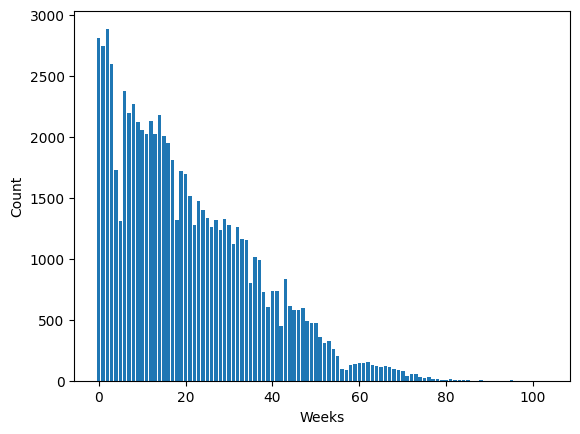

In [15]:

data = row[week_cols]

# Fix: Use column count for x-axis range and flatten values to 1D array
plt.bar(range(data.shape[1]), data.iloc[0].values)

plt.xlabel('Weeks')
plt.ylabel('Count')


Non-parametric Median Survival Time (KM Estimate): 18.00 weeks


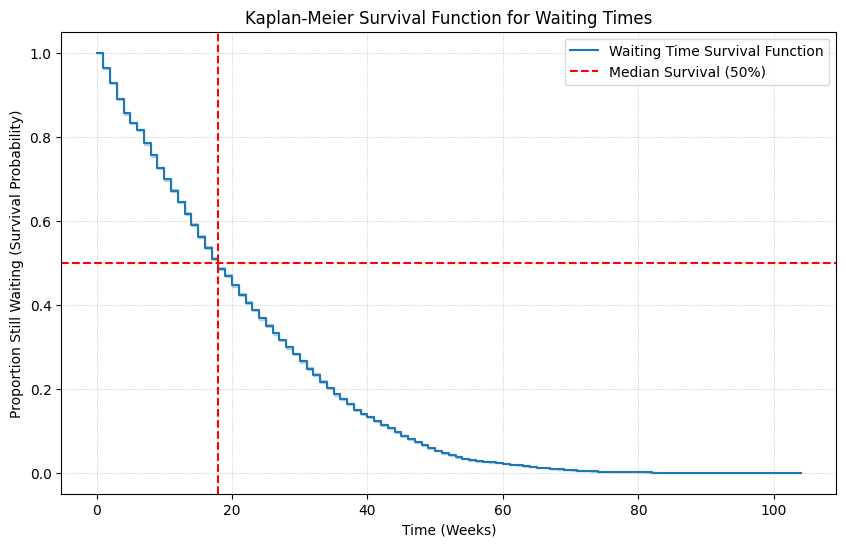

In [16]:


from nhs_waiting_lists.utils.reshaping import run_kaplan_meier_analysis

run_kaplan_meier_analysis(df_km)